In [1]:
#PACKAGES
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Load Dataset

We collect all the stablecoin datasets from the `clean_data` folder, and use the versions with a `_final` suffix. The datasets are then  combined together for the 'hybrid' PCA. 

In [2]:
# LOAD & COMBINE
files = glob.glob("../clean_data/*_final.parquet")

df_list = []
for file in files:
    temp = pd.read_parquet(file)
    coin_name = file.split("/")[-1].replace(".parquet", "").replace("_final", "")
    temp["coin"] = coin_name
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df

,Unnamed: 0,depeg,depeg_future_1d,depeg_future_3d,depeg_future_5d,depeg_future_7d,depeg_future_14d,depeg_future_30d,symbol,timestamp,...,peg_error,abs_peg_error,price_deviation_5d,price_deviation_30d,downward_price_deviation_5d,downward_price_deviation_30d,fear_greed_index,fear_greed_index_category,fed_funds_rate,coin
0,30.0,0,0,0,0,0,0,0,UST,2020-12-25 23:59:59,...,-0.001375,0.001375,0.002765,0.001560,0.002765,0.001541,94.0,Extreme Greed,0.09,ust
1,31.0,0,0,0,0,0,0,0,UST,2020-12-26 23:59:59,...,-0.002121,0.002121,0.002795,0.001605,0.002795,0.001589,93.0,Extreme Greed,0.09,ust
2,32.0,0,0,0,0,0,0,0,UST,2020-12-27 23:59:59,...,-0.000279,0.000279,0.002279,0.001604,0.002279,0.001587,91.0,Extreme Greed,0.09,ust
3,33.0,0,0,0,0,0,0,0,UST,2020-12-28 23:59:59,...,-0.001755,0.001755,0.002359,0.001631,0.002359,0.001615,92.0,Extreme Greed,0.09,ust
4,34.0,0,1,1,1,1,1,1,UST,2020-12-29 23:59:59,...,-0.002543,0.002543,0.001790,0.001694,0.001790,0.001679,91.0,Extreme Greed,0.09,ust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8141,NaN,0,0,0,0,0,0,0,DAI,2026-03-15 23:59:59,...,0.000016,0.000016,0.000087,0.000125,0.000086,0.000121,15.0,Extreme Fear,3.64,dai
8142,NaN,0,0,0,0,0,0,0,DAI,2026-03-16 23:59:59,...,-0.000119,0.000119,0.000100,0.000126,0.000099,0.000122,23.0,Extreme Fear,3.64,dai
8143,NaN,0,0,0,0,0,0,0,DAI,2026-03-17 23:59:59,...,-0.000100,0.000100,0.000107,0.000122,0.000107,0.000117,28.0,Fear,3.64,dai
8144,NaN,0,0,0,0,0,0,0,DAI,2026-03-18 23:59:59,...,-0.000113,0.000113,0.000117,0.000107,0.000117,0.000102,26.0,Fear,3.64,dai


In [3]:
END_DATE = pd.Timestamp("2022-05-10")

## Removing all data for UST after 2022-05-10 as it has since collapsed

df = df[
    (df["coin"] != "ust") |
    ((df["coin"] == "ust") & (df["timestamp"] <= END_DATE))
    ].copy()

We divide the stablecoins into 3 main coin types: fiat-backed (USDT, USDC, PAX/USDP), algorithmic (UST), crypto-backed (DAI). We will run PCA on the combined data of each of these coin types in subsequent steps. Performing PCA on data from the same stablecoin type allows us to identify shared instability factors for each coin type. 

In [4]:
# COIN TYPE MAPPING 
# 3 groups for PCA — fiat_backed is pooled (3 coins)
# crypto_backed (DAI) and algorithmic (UST) are individual PCA

COIN_TYPES = {
    "usdt": "fiat_backed",
    "usdc": "fiat_backed",
    "pax":  "fiat_backed",
    "dai":  "crypto_backed",
    "ust":  "algorithmic",
}
df["coin_type"] = df["coin"].map(COIN_TYPES)

# coins with test depeg events
EVAL_COINS = ["usdc", "dai", "ust", "pax", "usdt"]

In [5]:
# FEATURES

## A list of variables specific to each coin
COIN_FEATURES = [
    'percent_change_24h', 'percent_change_7d', 'percent_change_30d',
    'volume_percent_change_24h', 'volume_percent_change_7d', 'volume_percent_change_30d',
    'market_cap_percent_change_24h', 'market_cap_percent_change_7d', 'market_cap_percent_change_30d',
    'circulating_supply_percent_change_24h', 'circulating_supply_percent_change_7d',
    'circulating_supply_percent_change_30d',
    'realized_daily_volatility',
]

## A list of variables that affect all coins globally
MACRO_FEATURES = [
    'fear_greed_index',
    'fed_funds_rate'
]

features = COIN_FEATURES + MACRO_FEATURES ## a list of curated variables that are useful in detecting depegs

## Data Preprocessing

In [6]:
# CLEAN FEATURES
def clean_features(df, features):
    """
    Handles infinity and missing values in data. 
    Infinity values are treated as missing values. 
    The function first attempts to forward or backward fill missing values with data from the same coin. 
    If it is still missing, missing values are filled with 0.
    """
    df = df.copy()
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)
    df[features] = (
        df.groupby("coin")[features]
        .transform(lambda x: x.ffill().bfill())
        .fillna(0)
    )
    return df

# CLIP OUTLIERS
def clip_outliers(df_train, df_test, features, n_std=5):
    """
    Caps extreme values in the train and test set at ±5 of the train set's standard deviations (by default).
    Prevents PCA from being dominated by extreme spikes. 
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for col in features:
        mean = df_train[col].mean()
        std  = df_train[col].std()
        lo, hi = mean - n_std * std, mean + n_std * std
        df_train[col] = df_train[col].clip(lo, hi)
        df_test[col]  = df_test[col].clip(lo, hi)
    return df_train, df_test

We have chosen a global train-test split date of October 2021 across all 3 stages of our project's methodology. We apply the split on October 2021 here. 

In [7]:
# GLOBAL SPLIT
POOLED_SPLIT_DATE = "2021-10-01"

def split_by_date(df, split_date, date_col="timestamp"):
    """
    Splits the input dataset df into a train and test set. 
    Assigns all observations before split_date to the train set.
    Assigns all observations after split_date to the test set. 
    """
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    split_date = pd.Timestamp(split_date)
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    return train, test

In [8]:
## obtain train and test sets
df_train, df_test = split_by_date(df, POOLED_SPLIT_DATE) 

# clean after split to avoid fill leakage across boundary
df_train = clean_features(df_train, features)
df_test  = clean_features(df_test,  features)

# clip outliers
df_train, df_test = clip_outliers(df_train, df_test, features, n_std=5)

print(f"Data range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print("\nTrain coin counts:"); print(df_train["coin"].value_counts())
print("\nTest coin counts:");  print(df_test["coin"].value_counts())
print("\nTest depeg events:")
print(df_test.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

Data range: 2020-12-25 → 2026-03-19
Train: (1400, 45) | Test: (6745, 45)

Train coin counts:
coin
ust     280
usdc    280
dai     280
usdt    280
pax     280
Name: count, dtype: int64

Test coin counts:
coin
usdc    1631
usdt    1631
pax     1631
dai     1631
ust      221
Name: count, dtype: int64

Test depeg events:
depeg     0   1
coin           
dai    1617  14
pax    1600  31
usdc   1618  13
usdt   1613  18
ust     214   7


In [9]:
train_depegs = df_train.groupby("coin")["depeg"].sum()
test_depegs  = df_test.groupby("coin")["depeg"].sum()

depeg_compare = pd.concat(
    [train_depegs, test_depegs],
    axis=1,
    keys=["train_depegs", "test_depegs"]
).fillna(0)

## Displays the number of depeg events in the train and test set of each coin

print("\nDepeg counts per coin:")
print(depeg_compare)


Depeg counts per coin:
      train_depegs  test_depegs
coin                           
dai              9           14
pax              4           31
usdc            19           13
usdt            10           18
ust             25            7


In [10]:
## Display the number of depeg vs non-depeg events for each coin's data

print(df.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

depeg     0   1
coin           
dai    1888  23
pax    1876  35
usdc   1879  32
usdt   1883  28
ust     469  32


In [11]:
## Check earliest and latest depeg events for each coin

for coin, group in df.groupby("coin"):
    depegs = group[group["depeg"] == 1]["timestamp"]
    print(f"{coin}: {len(depegs)} depegs | earliest={depegs.min().date()} | latest={depegs.max().date()}")

dai: 23 depegs | earliest=2021-01-01 | latest=2023-03-12
pax: 35 depegs | earliest=2021-04-17 | latest=2024-07-01
usdc: 32 depegs | earliest=2021-01-07 | latest=2023-03-21
usdt: 28 depegs | earliest=2021-01-05 | latest=2026-02-04
ust: 32 depegs | earliest=2020-12-30 | latest=2022-05-09


In [12]:
## Sanity check to ensure all values in train and test sets are finite

for split_name, split_df in [("train", df_train), ("test", df_test)]:
    for col in features:
        bad = (~np.isfinite(split_df[col])).sum()
        if bad > 0:
            print(f"{split_name} {col}: {bad} bad values remaining")

## Hybrid Scaling

In this step, coin features are scaled per coin while macro features are scaled globally across all coins. This helps us preserve relative structure within coins while allowing shared macro influence. 

In [13]:
# HYBRID SCALING
# coin features -> per-coin StandardScaler fitted on train only
# macro features -> single global StandardScaler fitted on train only

coin_scalers = {}
scaled_train_list = []
scaled_test_list  = []

for coin, group in df_train.groupby("coin"):
    scaler = StandardScaler()
    scaled = group.copy()
    scaled[COIN_FEATURES] = scaler.fit_transform(group[COIN_FEATURES])
    coin_scalers[coin] = scaler
    scaled_train_list.append(scaled)

for coin, group in df_test.groupby("coin"):
    scaled = group.copy()
    scaled[COIN_FEATURES] = coin_scalers[coin].transform(group[COIN_FEATURES])
    scaled_test_list.append(scaled)

df_train_scaled = pd.concat(scaled_train_list).sort_values("timestamp").reset_index(drop=True)
df_test_scaled  = pd.concat(scaled_test_list).sort_values("timestamp").reset_index(drop=True)

# global scaler for macro features
macro_scaler = StandardScaler()
df_train_scaled[MACRO_FEATURES] = macro_scaler.fit_transform(df_train_scaled[MACRO_FEATURES])
df_test_scaled[MACRO_FEATURES]  = macro_scaler.transform(df_test_scaled[MACRO_FEATURES])

## Hybrid PCA: PCA by Coin Type

As mentioned above, we run PCA separately for the fiat-backed, crypto-collateralised and algorithmic stablecoins. This allows us to capture common structure among the fiat-backed stablecoins, and idiosyncratic structure for the crypto-backed and algorithmic stablecoins. 

In [14]:
# HYBRID POOLED PCA BY COIN TYPE
# fiat_backed  → genuinely pooled PCA (USDT, USDC, PAX)
# crypto_backed → individual PCA (DAI only)
# algorithmic  → individual PCA (UST only)

N_COMPONENTS = 0.95 

pca_models = {}

for coin_type, group_df in df_train_scaled.groupby("coin_type"):
    X = group_df[features].values

    ## choose the smallest number of PCs that together explain 95% of the total variance in data
    
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    pca.fit(X) ## PCA is run on combined data for each coin type
    pca_models[coin_type] = pca
    coins_in_group = group_df["coin"].unique().tolist()

    ## display the number of PCs and cumulative explained variance for each coin type 
    
    print(f"{coin_type} {coins_in_group}: {pca.n_components_} components, " 
          f"cumulative variance = {pca.explained_variance_ratio_.cumsum()[-1]:.4f}")

algorithmic ['ust']: 10 components, cumulative variance = 0.9542
crypto_backed ['dai']: 10 components, cumulative variance = 0.9547
fiat_backed ['usdc', 'usdt', 'pax']: 11 components, cumulative variance = 0.9708


## Signal Generation / Anomaly Detection: Reconstruction Error

We use reconstruction error as an anomaly (depeg) signal as PCA learns the normal structure of the data, so deviations from this normal structure (ie a depeg where prices drop drastically from the normal value) are learnt poorly, resulting in higher reconstruction error. A high reconstruction error is the signal we want to capture.

In [15]:
# RECONSTRUCTION ERROR
def compute_recon_error(df_scaled, pca_models, features):
    """
    Computes the reconstruction error from PCA for each coin type.
    """
    df_scaled = df_scaled.copy()
    df_scaled["recon_error"] = np.nan
    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca     = pca_models[coin_type]
        X       = group_df[features].values

        ## apply PCA to feature matrix X and obtain PCs
        ## try to reconstruct the original data from the obtained PCs and store as X_recon
        X_recon = pca.inverse_transform(pca.transform(X)) 

        ## compute reconstruction error
        ## reconstruction error is the average squared difference between the original data and reconstructed data
        
        df_scaled.loc[group_df.index, "recon_error"] = np.mean((X - X_recon) ** 2, axis=1)
    return df_scaled

df_train_scaled = compute_recon_error(df_train_scaled, pca_models, features)
df_test_scaled  = compute_recon_error(df_test_scaled,  pca_models, features)

## Display reconstruction error summary statistics for each coin type's train and test set

print("\nTrain recon_error stats:")
print(df_train_scaled.groupby("coin")["recon_error"].describe().round(4))
print("\nTest recon_error stats:")
print(df_test_scaled.groupby("coin")["recon_error"].describe().round(4))


Train recon_error stats:
      count    mean     std     min     25%     50%     75%     max
coin                                                               
dai   280.0  0.0453  0.0696  0.0001  0.0099  0.0236  0.0528  0.7320
pax   280.0  0.0367  0.1993  0.0000  0.0012  0.0054  0.0249  3.2288
usdc  280.0  0.0248  0.1311  0.0000  0.0010  0.0044  0.0136  2.0957
usdt  280.0  0.0261  0.1069  0.0000  0.0015  0.0050  0.0187  1.6505
ust   280.0  0.0458  0.0878  0.0001  0.0078  0.0200  0.0471  0.9443

Test recon_error stats:
       count    mean     std     min     25%     50%     75%      max
coin                                                                 
dai   1631.0  0.1224  0.5366  0.0001  0.0159  0.0323  0.0740  12.8751
pax   1631.0  0.0961  0.1807  0.0000  0.0072  0.0307  0.1056   2.2456
usdc  1631.0  0.0904  1.1719  0.0000  0.0078  0.0191  0.0359  35.7442
usdt  1631.0  0.0426  0.1884  0.0000  0.0064  0.0208  0.0448   7.1790
ust    221.0  0.0588  0.1159  0.0000  0.0117  0.0276 

In [16]:
# THRESHOLD SEARCH
# find cutoff for anomaly detection
# search per coin type so each group finds its own optimal threshold

print("\nThreshold search by coin type:")
for coin_type, group_df in df_test_scaled.groupby("coin_type"):
    train_group = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_group  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]
    eval_group  = test_group[test_group["coin"].isin(EVAL_COINS)]

    if eval_group.empty:
        continue

    print(f"\n  {coin_type}:")
    for p in [0.90, 0.93, 0.95, 0.97, 0.99]:
        thresholds_ct = train_group.groupby("coin")["recon_error"].quantile(p).to_dict()
        eval_group = eval_group.copy()
        eval_group["anomaly"] = (
                eval_group["recon_error"] > eval_group["coin"].map(thresholds_ct)
        ).astype(int) ## if reconstruction error > 100*p percentile of the coin's reconstruction error, it is considered an anomaly

        ## evaluation metrics
        
        precision_avg = eval_group.groupby("coin").apply(
            lambda g: precision_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        recall_avg = eval_group.groupby("coin").apply(
            lambda g: recall_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        f1_avg = eval_group.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        print(f"    p={p}  precision={precision_avg:.4f}  recall={recall_avg:.4f}  f1={f1_avg:.4f}")


Threshold search by coin type:

  algorithmic:
    p=0.9  precision=0.0400  recall=0.1429  f1=0.0625
    p=0.93  precision=0.0714  recall=0.1429  f1=0.0952
    p=0.95  precision=0.0769  recall=0.1429  f1=0.1000
    p=0.97  precision=0.0833  recall=0.1429  f1=0.1053
    p=0.99  precision=0.2500  recall=0.1429  f1=0.1818

  crypto_backed:
    p=0.9  precision=0.0381  recall=0.8571  f1=0.0729
    p=0.93  precision=0.0476  recall=0.8571  f1=0.0902
    p=0.95  precision=0.0574  recall=0.8571  f1=0.1076
    p=0.97  precision=0.0667  recall=0.7857  f1=0.1229
    p=0.99  precision=0.0638  recall=0.4286  f1=0.1111

  fiat_backed:
    p=0.9  precision=0.0274  recall=0.5040  f1=0.0520
    p=0.93  precision=0.0342  recall=0.4676  f1=0.0637
    p=0.95  precision=0.0481  recall=0.4490  f1=0.0864
    p=0.97  precision=0.0755  recall=0.3619  f1=0.1239
    p=0.99  precision=0.1606  recall=0.2818  f1=0.1966


In [17]:
#EVALUATION
def evaluate(df_test_scaled, thresholds, label_col, eval_coins):
    """
    For each coin (type), evaluate the anomaly detection performance on the test set using reconstruction error. 
    Applies coin-specific thresholds to reconstruction errors to generate binary anomaly signals.
    Compares these predictions to actual depeg labels. 
    Performance metrics are computed separately for each coin.
    """
    df_test_scaled = df_test_scaled.copy()
    df_test_scaled["anomaly"] = (
            df_test_scaled["recon_error"] > df_test_scaled["coin"].map(thresholds)
    ).astype(int)

    # only evaluate coins with test depeg events (all in this case)
    df_eval = df_test_scaled[df_test_scaled["coin"].isin(eval_coins)].copy()

    results = []
    for coin, group in df_eval.groupby("coin"):
        y_true = group[label_col].astype(bool)
        y_pred = group["anomaly"]

        precision   = precision_score(y_true, y_pred, zero_division=0)
        recall      = recall_score(y_true, y_pred, zero_division=0)
        f1          = f1_score(y_true, y_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        try:
            auc = roc_auc_score(y_true, group["recon_error"])
        except ValueError:
            auc = np.nan

        results.append({
            "coin":          coin,
            "coin_type":     COIN_TYPES.get(coin, "unknown"),
            "precision":     round(precision,   4),
            "recall":        round(recall,      4),
            "f1":            round(f1,          4),
            "specificity":   round(specificity, 4),
            "auc_roc":       round(auc, 4) if not np.isnan(auc) else np.nan,
            "n_anomalies":   int(y_pred.sum()),
            "n_true_depegs": int(y_true.sum()),
            "threshold":     round(thresholds.get(coin, np.nan), 6)
        })

    return pd.DataFrame(results)

In [18]:
# FINAL EVALUATION 
# per coin threshold
THRESHOLD_PERCENTILE = 0.99

thresholds = df_train_scaled.groupby("coin")["recon_error"].quantile(THRESHOLD_PERCENTILE).to_dict()

print("\n── Results: depeg_future_1d ──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_1d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_3d──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_3d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_7d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_7d", EVAL_COINS)
print(results_7d.to_string(index=False))

print("\n── Results: depeg_future_14d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_14d", EVAL_COINS)
print(results_7d.to_string(index=False))


── Results: depeg_future_1d ──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.0426  0.2857 0.0741       0.9443   0.7915           94             14   0.304495
 pax   fiat_backed     0.0560  0.2258 0.0897       0.9262   0.6336          125             31   0.319177
usdc   fiat_backed     0.2000  0.2308 0.2143       0.9926   0.6729           15             13   0.225077
usdt   fiat_backed     0.1290  0.2222 0.1633       0.9833   0.7433           31             18   0.205947
 ust   algorithmic     0.2500  0.1250 0.1667       0.9859   0.6156            4              8   0.423288

── Results: depeg_future_3d──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.1489  0.4242 0.2205       0.9499   0.8637           94             33   0.304495
 pax   fiat_backed     0.2000  0.3049 0.2415       0.9354   0.7175          125          

## Analysing PC Loadings

To understand the dominant factors contributing to the best-performing PCs for each coin type, we proceeded to analyse the loadings on the top 3 PCs for each coin type. We computed the reconstruction error of each PC, then repeated the thresholding and evaluation steps above to obtain the F1 metric, which we used to compare PC performance and select the top 3 PCs for each coin type. 

In [19]:
# =========================
# INDIVIDUAL PC EVALUATION
# =========================

def compute_recon_error_subset(df_scaled, pca_models, features, pc_index):
    """
    For every coin type, computes the reconstruction error for each PC generated
    """
    df_scaled = df_scaled.copy()
    df_scaled["recon_error_subset"] = np.nan

    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca = pca_models[coin_type]
        X = group_df[features].values

        Z = pca.transform(X)

        # keep only ONE PC
        Z_subset = np.zeros_like(Z)
        Z_subset[:, pc_index] = Z[:, pc_index]

        X_recon = pca.inverse_transform(Z_subset)

        err = np.mean((X - X_recon) ** 2, axis=1)
        df_scaled.loc[group_df.index, "recon_error_subset"] = err

    return df_scaled


results_pc = []

for coin_type, pca in pca_models.items():
    n = pca.n_components_ ## number of PCs n = 11 for fiat-backed stablecoins, n = 10 for algorithmic and crypto-backed stablecoins

    train_ct = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_ct  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]

    for i in range(n):
        train_temp = compute_recon_error_subset(train_ct, pca_models, features, i)
        test_temp  = compute_recon_error_subset(test_ct,  pca_models, features, i)

        thresholds = train_temp.groupby("coin")["recon_error_subset"].quantile(0.99).to_dict()

        eval_df = test_temp[test_temp["coin"].isin(EVAL_COINS)].copy()
        eval_df["anomaly"] = (
            eval_df["recon_error_subset"] > eval_df["coin"].map(thresholds)
        ).astype(int) ## anomaly = reconstruction error > 99th percentile of the coin's reconstruction error\

        ## produce F1 comparison metric

        f1 = eval_df.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()

        results_pc.append({
            "coin_type": coin_type,
            "pc": f"PC{i+1}",
            "pc_index": i,
            "f1": f1
        })

results_df = pd.DataFrame(results_pc)

# sort and get top 3
results_df_sorted = results_df.sort_values(["coin_type", "f1"], ascending=[True, False])
top3_pcs = results_df_sorted.groupby("coin_type").head(3)

## Display the top 3 PCs by coin type 

print("\nTop 3 PCs by coin type:")
print(top3_pcs)


Top 3 PCs by coin type:
        coin_type    pc  pc_index        f1
2     algorithmic   PC3         2  0.285714
0     algorithmic   PC1         0  0.250000
1     algorithmic   PC2         1  0.250000
13  crypto_backed   PC4         3  0.263158
14  crypto_backed   PC5         4  0.235294
19  crypto_backed  PC10         9  0.235294
23    fiat_backed   PC4         3  0.187361
20    fiat_backed   PC1         0  0.186789
21    fiat_backed   PC2         1  0.175099


After obtaining the top 3 PCs for each coin type, we proceed to analyse the loadings of the PCs to understand the influence / contribution of each feature on the PC. The loadings are displayed in the form of heatmaps for better visualisation. 

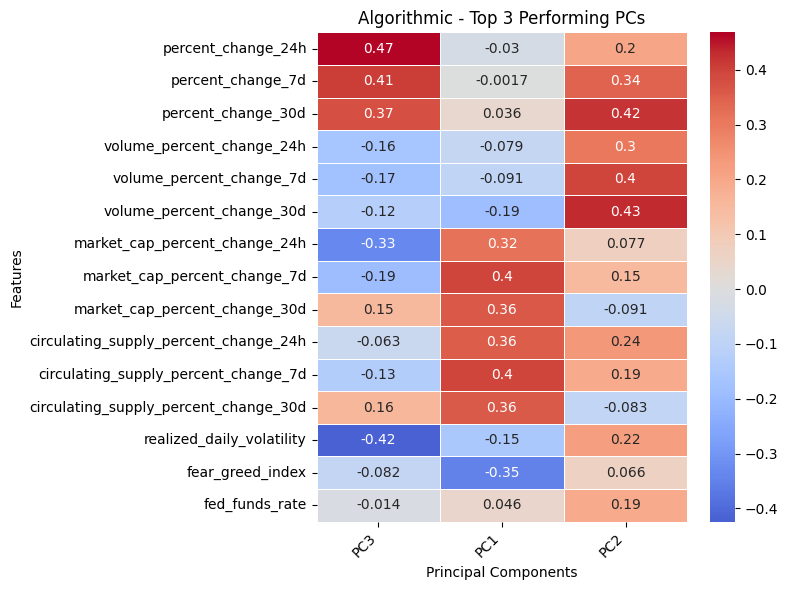

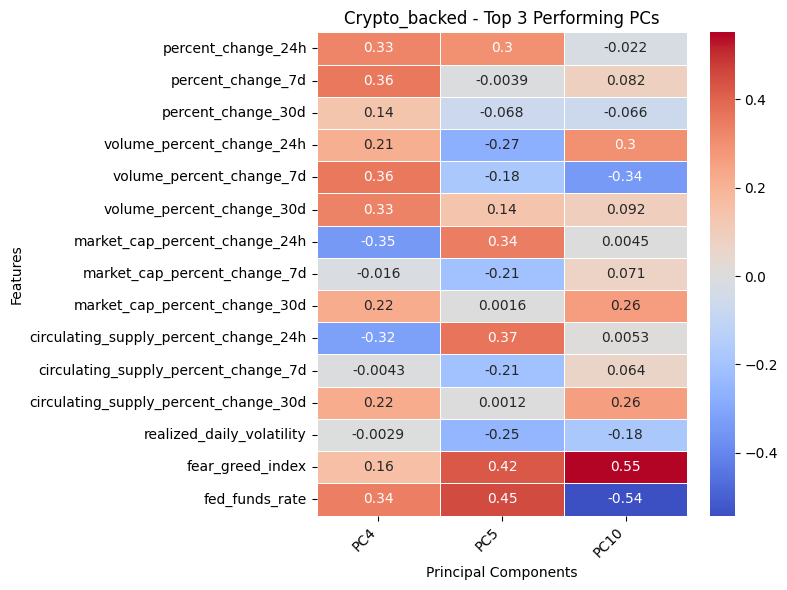

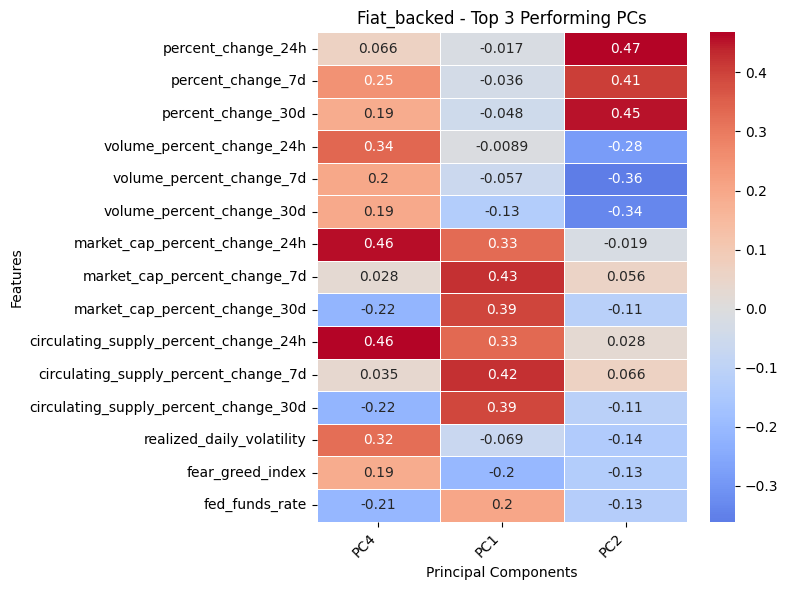

In [20]:
# =========================
# HEATMAPS FOR TOP 3 PCs
# =========================

for coin_type, pca in pca_models.items():
    
    pcs = top3_pcs[top3_pcs["coin_type"] == coin_type]["pc_index"].tolist()
    
    if len(pcs) == 0:
        continue

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    selected_cols = [f'PC{i+1}' for i in pcs]
    loadings_top3 = loadings_df[selected_cols]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        loadings_top3,
        cmap='coolwarm',
        center=0,
        annot=True,
        linewidths=0.5
    )

    plt.title(f"{coin_type.capitalize()} - Top 3 Performing PCs")
    plt.xlabel("Principal Components")
    plt.ylabel("Features")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Z-Score Anomaly Detection

Prior to the reconstruction error method above, an alternative z-score anomaly detection method was attempted. Stage 1 and Stage 2 of this project used z-scores to detect depegs and generate signals, so this was attempted for Stage 3 as well. However, the results seemed to be sub-optimal so this method was not ultimately not used. 

In [21]:
# =========================
# Z-SCORE ANOMALY DETECTION
# =========================

def compute_pc_scores(df_scaled, pca_models, features):
    """
    Project scaled data into PCA space to obtain PC scores.
    PC scores represent the coordinates of each observation in the PCA space and are used subsequently for z-score anomaly detection.
    """
    df_scaled = df_scaled.copy()
    
    pc_scores_dict = {}
    
    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca = pca_models[coin_type]
        X = group_df[features].values
        Z = pca.transform(X)
        
        pc_cols = [f"PC{i+1}" for i in range(Z.shape[1])]
        pc_df = pd.DataFrame(Z, index=group_df.index, columns=pc_cols)
        
        pc_scores_dict[coin_type] = pc_df
    
    return pc_scores_dict


# Step 1 & 2: Get PC scores
train_pc_scores = compute_pc_scores(df_train_scaled, pca_models, features)
test_pc_scores  = compute_pc_scores(df_test_scaled,  pca_models, features)


# Step 3: Compute Z-scores based on training distribution
zscore_results = []

Z_THRESHOLD = 3.0   # follow z-score threshold from Stage 2: 3 standard deviations

for coin_type in pca_models.keys():
    
    train_scores = train_pc_scores[coin_type]
    test_scores  = test_pc_scores[coin_type]
    
    # compute mean and std from TRAIN
    mu = train_scores.mean()
    sigma = train_scores.std().replace(0, 1e-8)
    
    # compute z-scores
    z_test = (test_scores - mu) / sigma
    
    # aggregate signal across PCs
    # max absolute z-score across PCs
    z_agg = z_test.abs().max(axis=1)
    
    # store back into df
    test_idx = test_scores.index
    df_test_scaled.loc[test_idx, "zscore"] = z_agg


# Step 4: Thresholding and evaluation
print("\nZ-score method results:")

df_test_scaled["anomaly_z"] = (df_test_scaled["zscore"] >= Z_THRESHOLD).astype(int)

for horizon in ["depeg_future_1d", "depeg_future_3d", "depeg_future_7d", "depeg_future_14d"]:
    results_z = []
    for coin, group in df_test_scaled[df_test_scaled["coin"].isin(EVAL_COINS)].groupby("coin"):
    
        y_true = group[horizon].astype(bool)
        y_pred = group["anomaly_z"]
    
        precision   = precision_score(y_true, y_pred, zero_division=0)
        recall      = recall_score(y_true, y_pred, zero_division=0)
        f1          = f1_score(y_true, y_pred, zero_division=0)
    
        try:
            auc = roc_auc_score(y_true, group["zscore"])
        except ValueError:
            auc = np.nan

        results_z.append({
            "coin": coin,
            "coin_type": COIN_TYPES.get(coin, "unknown"),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
            "auc_roc": round(auc, 4) if not np.isnan(auc) else np.nan,
            "n_anomalies": int(y_pred.sum()),
            "n_true_depegs": int(y_true.sum())
        })

        results_z_df = pd.DataFrame(results_z)

    print(f"\n── Z-score Results: {horizon}")
    print(results_z_df.to_string(index=False))


Z-score method results:

── Z-score Results: depeg_future_1d
coin     coin_type  precision  recall     f1  auc_roc  n_anomalies  n_true_depegs
 dai crypto_backed     0.0111  0.5714 0.0219   0.5947          718             14
 pax   fiat_backed     0.0204  0.9355 0.0399   0.5544         1421             31
usdc   fiat_backed     0.0050  0.3846 0.0098   0.3816         1006             13
usdt   fiat_backed     0.0178  1.0000 0.0350   0.8027         1010             18
 ust   algorithmic     0.0606  0.5000 0.1081   0.5100           66              8

── Z-score Results: depeg_future_3d
coin     coin_type  precision  recall     f1  auc_roc  n_anomalies  n_true_depegs
 dai crypto_backed     0.0306  0.6667 0.0586   0.6826          718             33
 pax   fiat_backed     0.0542  0.9390 0.1025   0.5941         1421             82
usdc   fiat_backed     0.0070  0.2121 0.0135   0.2420         1006             33
usdt   fiat_backed     0.0297  0.9375 0.0576   0.7694         1010             32